### **1. Importación de librerías y Configuración**

In [2]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt

# Configuración de carpetas
RAW = "/content/drive/MyDrive/TFG/raw"
os.makedirs(RAW, exist_ok=True)
os.makedirs("/content/drive/MyDrive/TFG/models_final", exist_ok=True)
os.makedirs("/content/drive/MyDrive/TFG/processed", exist_ok=True)

### **2. Descompresión**
*No ejecutar si los zips ya están descomprimidos*

In [ ]:
def unzip_selected_months(year, months):
    year_dir = f"{RAW}/{year}"
    monthly_zips = glob.glob(f"{year_dir}/*.zip")

    extracted = 0
    for mzip in monthly_zips:
        zip_name = os.path.basename(mzip)
        for m in months:
            expected = f"{m}-{year}.zip"
            if zip_name == expected:
                out_dir = os.path.join(year_dir, f"{m}-{year}")
                os.makedirs(out_dir, exist_ok=True)
                with zipfile.ZipFile(mzip, 'r') as zip_ref:
                    zip_ref.extractall(out_dir)
                extracted += 1
    print(f"[SUCCESS] {extracted} carpetas extraídas/verificadas.")

# Extraemos solo los meses de interés (mayo - julio)
unzip_selected_months(2025, months=["05", "06", "07"])

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **3. Carga y concatenación de los datos**
*Datos de los meses: mayo, junio y julio de 2025*

In [3]:
def load_month_robust(path, sensor_id):
    all_files = glob.glob(f"{path}/*.csv")
    data_list = []

    for f in all_files:
        try:
            # Intento 1: Separador estándar de Madrid (;)
            df = pd.read_csv(f, sep=';', on_bad_lines='skip', engine='python')

            # Intento 2: Si falla o lee todo en una columna, probamos con coma (,)
            if df.shape[1] <= 1:
                df = pd.read_csv(f, sep=',', on_bad_lines='skip', engine='python')

            # Buscar la columna ID (a veces cambia de nombre)
            col_id = 'id' if 'id' in df.columns else ('identificador' if 'identificador' in df.columns else None)

            if col_id and not df.empty:
                target = df[df[col_id] == sensor_id]
                if not target.empty:
                    data_list.append(target)

        except Exception as e:
            # Si un archivo está totalmente corrupto (0 KB), lo salta sin romper el programa
            print(f"[ERROR] Saltando archivo corrupto {os.path.basename(f)}: {e}")
            continue

    return pd.concat(data_list, ignore_index=True) if data_list else pd.DataFrame()

def build_dataset(year, months):
    year_dir = f"{RAW}/{year}"
    dfs = []
    for m in months:
        folder = f"{m}-{year}"
        path = os.path.join(year_dir, folder)
        if os.path.exists(path):
            print(f"[INFO] Procesando {folder}...")
            df_m = load_month_robust(path, sensor_id=3488)
            if not df_m.empty:
                dfs.append(df_m)
                print(f" --> {len(df_m)} registros cargados.")
            else:
                print(f"[ERROR] Sin datos para el sensor 3488 en {folder}.")

    df_final = pd.concat(dfs, ignore_index=True)
    df_final['fecha'] = pd.to_datetime(df_final['fecha'], errors='coerce')
    df_final = df_final.dropna(subset=['fecha']).sort_values('fecha').set_index('fecha')
    return df_final

df_raw = build_dataset(2025, ["05", "06", "07"])
print(f"[SUCCESS] Dataset total: {df_raw.shape}")

[INFO] Procesando 05-2025...
 --> 2976 registros cargados.
[INFO] Procesando 06-2025...
 --> 2854 registros cargados.
[INFO] Procesando 07-2025...
 --> 2976 registros cargados.
[SUCCESS] Dataset total: (8806, 8)


### **4. Preprocesamiento y Variables de Contexto**
*Definición de días festivos, fines de semana y horas puntas para cada día*

In [4]:
df_pro = df_raw.copy()

# Rellenar huecos vacíos si el sensor falló algún rato
df_pro = df_pro.resample('15min').ffill().bfill()

# --- INGENIERÍA DE CARACTERÍSTICAS ---
# 1. Variables Temporales
df_pro['hora'] = df_pro.index.hour
df_pro['dia_semana'] = df_pro.index.weekday

# 2. Contexto Avanzado
df_pro['is_weekend'] = df_pro['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)
df_pro['is_rush_hour'] = df_pro['hora'].apply(lambda x: 1 if (7<=x<=9) or (14<=x<=16) or (18<=x<=20) else 0)

# Festivos (Ajusta los días si es necesario)
festivos = ['2025-05-01', '2025-05-02', '2025-05-15', '2025-07-25']
df_pro['is_holiday'] = df_pro.index.normalize().isin(pd.to_datetime(festivos)).astype(int)

print("[SUCCESS] Preprocesamiento completado. Columnas disponibles:")
print(df_pro.columns.tolist())

[SUCCESS] Preprocesamiento completado. Columnas disponibles:
['id', 'tipo_elem', 'intensidad', 'ocupacion', 'carga', 'vmed', 'error', 'periodo_integracion', 'hora', 'dia_semana', 'is_weekend', 'is_rush_hour', 'is_holiday']


### **5. División Train/Test y Función de Ventanas deslizantes**

In [5]:
# --- 1. SEPARACIÓN 80 train / 20 test ---
split_idx = int(len(df_pro) * 0.8)
df_train = df_pro.iloc[:split_idx]
df_test = df_pro.iloc[split_idx:]

print(f"Train (80%): {df_train.index.min().date()} a {df_train.index.max().date()}")
print(f"Test (20%): {df_test.index.min().date()} a {df_test.index.max().date()}")

# Función para crear ventanas LSTM
def create_sequences(data, window_size=672):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size, 0]) # Posición 0 asumimos que es 'intensidad'
    return np.array(X), np.array(y)

Train (80%): 2025-05-01 a 2025-07-13
Test (20%): 2025-07-13 a 2025-07-31


### **6. MODELO 1 - Vanilla LSTM: Multivariante Básico**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

# Misma paciencia (15) y sin min_delta para que ambos den su máximo absoluto
early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# --- 2. MODELO 1: BASE (1 Capa, Variables Básicas) ---
print("--- Entrenando Modelo 1 (Base) - Configuración Final ---")
model_1 = Sequential([
    # Usamos tanh por defecto y Dropout 0.1 para igualdad de condiciones
    LSTM(64, activation='tanh', input_shape=(X_train_m1.shape[1], X_train_m1.shape[2])),
    Dropout(0.1),
    Dense(1)
])

opt_1 = Adam(learning_rate=0.0001, clipnorm=1.0)
model_1.compile(optimizer=opt_1, loss='mse')

history_1 = model_1.fit(
    X_train_m1, y_train_m1,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

--- Entrenando Modelo 1 (Base) - Configuración Final ---
Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 33s 175ms/step - loss: 0.0673 - val_loss: 0.0200
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - loss: 0.0151 - val_loss: 0.0110
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - loss: 0.0104 - val_loss: 0.0066
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - loss: 0.0085 - val_loss: 0.0057
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - loss: 0.0079 - val_loss: 0.0053
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 31s 173ms/step - loss: 0.0072 - val_loss: 0.0047
Epoch 7/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 31s 170ms/step - loss: 0.0067 - val_loss: 0.0047
Epoch 8/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - loss: 0.0062 - val_loss: 0.0041
Epoch 9/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 41s 174ms/step - loss: 0.0059 - val_loss: 0.0038
Epoch 10/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 31s 170ms/step - loss: 0.0056 - val_loss: 0.0036
Epoch 11/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 

### **7. MODELO 2 - Stacked LSTM: Multivariante PRO** (Multivariante + Contexto Completo)

In [ ]:
print("--- Entrenando Modelo 2 (PRO) - Desbloqueado ---")
model_2 = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train_m2.shape[1], X_train_m2.shape[2])),
    Dropout(0.1),
    LSTM(32, activation='tanh'),
    Dense(1)
])

# Volvemos al learning_rate estándar (0.001)
# El clipnorm y la activación tanh ya evitarán los NaNs
opt_2 = Adam(learning_rate=0.001, clipnorm=1.0)
model_2.compile(optimizer=opt_2, loss='mse')

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_2 = model_2.fit(
    X_train_m2, y_train_m2,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

--- Entrenando Modelo 2 (PRO) - Desbloqueado ---
Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 71s 374ms/step - loss: 0.0131 - val_loss: 0.0039
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 67s 370ms/step - loss: 0.0046 - val_loss: 0.0025
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 67s 374ms/step - loss: 0.0037 - val_loss: 0.0023
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 82s 374ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 81s 371ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 83s 377ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 7/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 81s 373ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 8/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 69s 381ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 9/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 68s 376ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 10/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 70s 387ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 11/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 82s 389m

### **8. Guardado de modelos**

In [ ]:
# --- GUARDAR MODELO 1 (BÁSICO) ---
print("Guardando Modelo 1...")
model_1.save('/content/drive/MyDrive/TFG/models_final/model_1/traffic_model_basic2.0.keras')
joblib.dump(scaler_m1, '/content/drive/MyDrive/TFG/models_final/model_1/scaler_basic2.0.pkl')
joblib.dump(cols_m1, '/content/drive/MyDrive/TFG/models_final/model_1/columnas_basic2.0.pkl')

Guardando Modelo 1...


['/content/drive/MyDrive/TFG/models_final/model_1/columnas_basic2.0.pkl']

In [ ]:
# --- GUARDAR MODELO 2 (PRO - ACTUAL) ---
print("Guardando Modelo 2...")
model_2.save('/content/drive/MyDrive/TFG/models_final/model_2/traffic_model_pro2.0.keras')
joblib.dump(scaler_m2, '/content/drive/MyDrive/TFG/models_final/model_2/scaler_pro2.0.pkl')
joblib.dump(cols_m2, '/content/drive/MyDrive/TFG/models_final/model_2/columnas_pro2.0.pkl')

# --- GUARDAR DATOS PROCESADOS (Para el histórico de la App) ---
df_pro.to_csv('/content/drive/MyDrive/TFG/processed/datos_procesados2.csv')

Guardando Modelo 2...


### **9. Carga de los modelos desde GDrive**

In [6]:
import joblib

# Definimos las rutas
path_scaler_basico = "/content/drive/MyDrive/TFG/models_final/model_1/scaler_basic2.0.pkl"
path_scaler_pro = "/content/drive/MyDrive/TFG/models_final/model_2/scaler_pro2.0.pkl"

# Cargamos los objetos
scaler_basico = joblib.load(path_scaler_basico)
scaler_pro = joblib.load(path_scaler_pro)

# Definimos las columnas
cols_basico = ['intensidad', 'ocupacion', 'carga']
cols_pro = ['intensidad', 'ocupacion', 'carga', 'is_weekend', 'is_holiday', 'sin_hour', 'cos_hour']

print("[SUCCESS] Escaladores y columnas cargados correctamente.")

[SUCCESS] Escaladores y columnas cargados correctamente.


In [7]:
import numpy as np
import pandas as pd

# 1. Preparación de nombres
if 'vmed' in df_raw.columns and 'carga' not in df_raw.columns:
    df_raw = df_raw.rename(columns={'vmed': 'carga'})

# 2. Filtrado para Julio
anio_detectado = df_raw.index.year.max()
df_test_raw = df_raw[(df_raw.index.month == 7) & (df_raw.index.year == anio_detectado)].copy()

if df_test_raw.empty:
    print(f"[ERROR] No hay datos para Julio de {anio_detectado}.")
else:
    # 3. INGENIERÍA DE VARIABLES (Adaptada al Modelo PRO)
    # Calculamos fin de semana
    df_test_raw['is_weekend'] = df_test_raw.index.weekday.isin([5, 6]).astype(int)

    # Definimos las horas puntas 'is_rush_hour' :
    # (7-9h), (14-16h) y (18-20h)
    df_test_raw['is_rush_hour'] = df_test_raw.index.hour.map(
        lambda x: 1 if (7<=x<=9) or (14<=x<=16) or (18<=x<=20) else 0
    )

    # Marcamos festivos (puedes añadir los de julio si quieres, o dejarlo a 0)
    festivos_julio = ['2025-07-25'] # Santiago Apóstol
    df_test_raw['is_holiday'] = df_test_raw.index.normalize().isin(pd.to_datetime(festivos_julio)).astype(int)

    # 4. DEFINICIÓN DE COLUMNAS
    cols_basico = ['intensidad', 'ocupacion', 'carga']
    cols_pro = ['intensidad', 'ocupacion', 'carga', 'is_weekend', 'is_rush_hour', 'is_holiday']

    try:
        # 5. ESCALADO
        # Modelo Básico
        df_test_m1_scaled = pd.DataFrame(
            scaler_basico.transform(df_test_raw[cols_basico]),
            columns=cols_basico, index=df_test_raw.index
        )

        # Modelo PRO
        df_test_m2_scaled = pd.DataFrame(
            scaler_pro.transform(df_test_raw[cols_pro]),
            columns=cols_pro, index=df_test_raw.index
        )

        df_test = df_test_m2_scaled
        print("[SUCCESS] El modelo PRO ha reconocido sus columnas: intensidad, ocupacion, carga, is_weekend, is_rush_hour e is_holiday.")

    except ValueError as e:
        print(f"[ERROR] Error de validación: {e}")
    except Exception as e:
        print(f"[ERROR] Error: {e}")

[SUCCESS] El modelo PRO ha reconocido sus columnas: intensidad, ocupacion, carga, is_weekend, is_rush_hour e is_holiday.


In [8]:

# 1. Definimos el tamaño de ventana (una semana = 672 intervalos)
window_size = 672

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# 2. Generamos de nuevo X_test e y_test para ambos modelos
# Modelo 1 (Básico): Usa solo las columnas básicas
data_test_m1 = df_test[cols_basico].values
X_test_m1, y_test_m1 = create_sequences(data_test_m1, window_size)

# Modelo 2 (PRO): Usa todas las columnas: festivos, horas, etc.
data_test_m2 = df_test[cols_pro].values
X_test_m2, y_test_m2 = create_sequences(data_test_m2, window_size)

print(f"[SUCCESS] Variables listas: X_test_m1 {X_test_m1.shape}, X_test_m2 {X_test_m2.shape}")

[SUCCESS] Variables listas: X_test_m1 (2304, 672, 3), X_test_m2 (2304, 672, 6)


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from tensorflow.keras.models import load_model

# --- 1. CARGAMOS LOS MODELOS Y ESCALADORES YA ENTRENADOS ---
path = '/content/drive/MyDrive/TFG/models_final'

try:
    print("[INFO] Cargando modelos desde disco...")

    # Modelo 1 (Asegúrate de que los nombres de archivo sean correctos)
    model_1 = load_model(f'{path}/model_1/traffic_model_basic2.0.keras')
    scaler_m1 = joblib.load(f'{path}/model_1/scaler_basic2.0.pkl')
    cols_m1 = joblib.load(f'{path}/model_1/columnas_basic2.0.pkl')

    # Modelo 2
    model_2 = load_model(f'{path}/model_2/traffic_model_pro2.0.keras')
    scaler_m2 = joblib.load(f'{path}/model_2/scaler_pro2.0.pkl')
    cols_m2 = joblib.load(f'{path}/model_2/columnas_pro2.0.pkl')

    print("[SUCCESS] Modelos y 'scalers' cargados correctamente.")
except Exception as e:
    print(f"[ERROR] Error crítico al cargar: {e}\nRevisa la ruta y los nombres de los archivos.")

# --- 2. GENERAMOS PREDICCIONES Y DESESCALAMOS ---
print("[INFO] Generando predicciones sobre el conjunto de Test...")

def unscale_predictions(preds, scaler, num_cols):
    dummy = np.zeros((len(preds), num_cols))
    dummy[:, 0] = preds[:, 0]
    return scaler.inverse_transform(dummy)[:, 0]

# Predicciones crudas (escaladas)
pred_m1_scaled = model_1.predict(X_test_m1)
pred_m2_scaled = model_2.predict(X_test_m2)

# Desescalamos a vehículos/hora
pred_m1_real = unscale_predictions(pred_m1_scaled, scaler_m1, len(cols_m1))
pred_m2_real = unscale_predictions(pred_m2_scaled, scaler_m2, len(cols_m2))
y_test_real = unscale_predictions(y_test_m1.reshape(-1, 1), scaler_m1, len(cols_m1))

# --- 3. CREAMOS UN DATAFRAME GLOBAL PARA FACILITAR LOS CÁLCULOS LUEGO ---
# Aseguramos que df_test.index esté alineado con y_test_real
window_size = 672 # 1 semana de histórico
fechas_test = df_test.index[window_size:]

df_resultados = pd.DataFrame({
    'Realidad': y_test_real,
    'Basico': pred_m1_real,
    'PRO': pred_m2_real
}, index=fechas_test)

print("[SUCCESS] Predicciones listas para analizar.")

[INFO] Cargando modelos desde disco...
[SUCCESS] Modelos y 'scalers' cargados correctamente.
[INFO] Generando predicciones sobre el conjunto de Test...
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step
[SUCCESS] Predicciones listas para analizar.


### **10. Métricas de Error (MAE, RMSE y R²)**

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Calculamos métricas para el Modelo 1
mae_m1 = mean_absolute_error(y_test_real, pred_m1_real)
rmse_m1 = np.sqrt(mean_squared_error(y_test_real, pred_m1_real))
r2_m1 = r2_score(y_test_real, pred_m1_real)

# Calculamos métricas para el Modelo 2 (Pro)
mae_m2 = mean_absolute_error(y_test_real, pred_m2_real)
rmse_m2 = np.sqrt(mean_squared_error(y_test_real, pred_m2_real))
r2_m2 = r2_score(y_test_real, pred_m2_real)

# Mostrar tabla comparativa
metrics_data = {
    'Métrica': ['MAE (Error Medio Absoluto)', 'RMSE (Error Cuadrático Medio)', 'R² (Precisión)'],
    'Modelo 1 (Básico)': [f"{mae_m1:.2f} veh/h", f"{rmse_m1:.2f} veh/h", f"{r2_m1:.4f}"],
    'Modelo 2 (PRO)': [f"{mae_m2:.2f} veh/h", f"{rmse_m2:.2f} veh/h", f"{r2_m2:.4f}"]
}

df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)

print("\n--- Interpretación para la memoria ---")
improvement = ((mae_m1 - mae_m2) / mae_m1) * 100
print(f"El Modelo PRO reduce el error medio en un {improvement:.2f}% respecto al básico.")

# Calculamos el volumen medio real para obtener una tasa de acierto porcentual robusta
mean_traffic = np.mean(y_test_real)
error_percent_m1 = (mae_m1 / mean_traffic) * 100
error_percent_m2 = (mae_m2 / mean_traffic) * 100

# Completamos tu lógica: 100 menos el porcentaje de error
accuracy_m1 = 100 - error_percent_m1
accuracy_m2 = 100 - error_percent_m2

print(f"La tasa de acierto del Modelo 1 (Básico) es del {accuracy_m1:.2f}%.")
print(f"La tasa de acierto del Modelo 2 (PRO) es del {accuracy_m2:.2f}%.")

,Métrica,Modelo 1 (Básico),Modelo 2 (PRO)
0,MAE (Error Medio Absoluto),144.10 veh/h,133.29 veh/h
1,RMSE (Error Cuadrático Medio),201.64 veh/h,190.64 veh/h
2,R² (Precisión),0.9701,0.9733



--- Interpretación para la memoria ---
El Modelo PRO reduce el error medio en un 7.50% respecto al básico.
La tasa de acierto del Modelo 1 (Básico) es del 92.86%.
La tasa de acierto del Modelo 2 (PRO) es del 93.40%.


### **11: Comparativa Visual:** *Predicción vs Realidad en Julio*

72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step


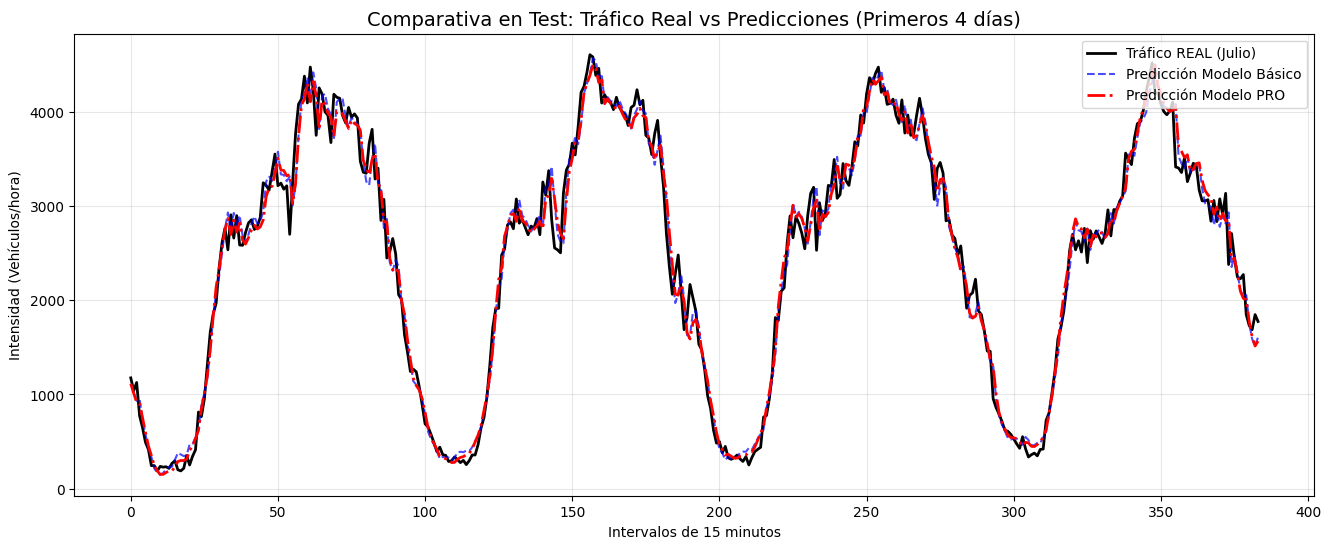

In [11]:
# --- Función para deshacer el escalado de forma segura ---
def unscale_predictions(preds, scaler, num_cols):
    dummy = np.zeros((len(preds), num_cols))
    dummy[:, 0] = preds[:, 0] # Ponemos las predicciones en la columna 0 (intensidad)
    return scaler.inverse_transform(dummy)[:, 0]

# 1. Generamos predicciones con los datos de Test
pred_m1_scaled = model_1.predict(X_test_m1)
pred_m2_scaled = model_2.predict(X_test_m2)

# 2. Deshacemos el escalado para ver coches/hora reales
pred_m1_real = unscale_predictions(pred_m1_scaled, scaler_m1, len(cols_m1))
pred_m2_real = unscale_predictions(pred_m2_scaled, scaler_m2, len(cols_m2))
y_test_real = unscale_predictions(y_test_m1.reshape(-1, 1), scaler_m1, len(cols_m1))

# 3. Dibujamos los primeros 4 días del conjunto de Test (4 días * 96 cuartos de hora = 384 puntos)
dias_a_mostrar = 384

plt.figure(figsize=(16, 6))
plt.plot(y_test_real[:dias_a_mostrar], label='Tráfico REAL (Julio)', color='black', linewidth=2)
plt.plot(pred_m1_real[:dias_a_mostrar], label='Predicción Modelo Básico', color='blue', linestyle='--', alpha=0.7)
plt.plot(pred_m2_real[:dias_a_mostrar], label='Predicción Modelo PRO', color='red', linestyle='-.', linewidth=2)

plt.title('Comparativa en Test: Tráfico Real vs Predicciones (Primeros 4 días)', fontsize=14)
plt.xlabel('Intervalos de 15 minutos')
plt.ylabel('Intensidad (Vehículos/hora)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

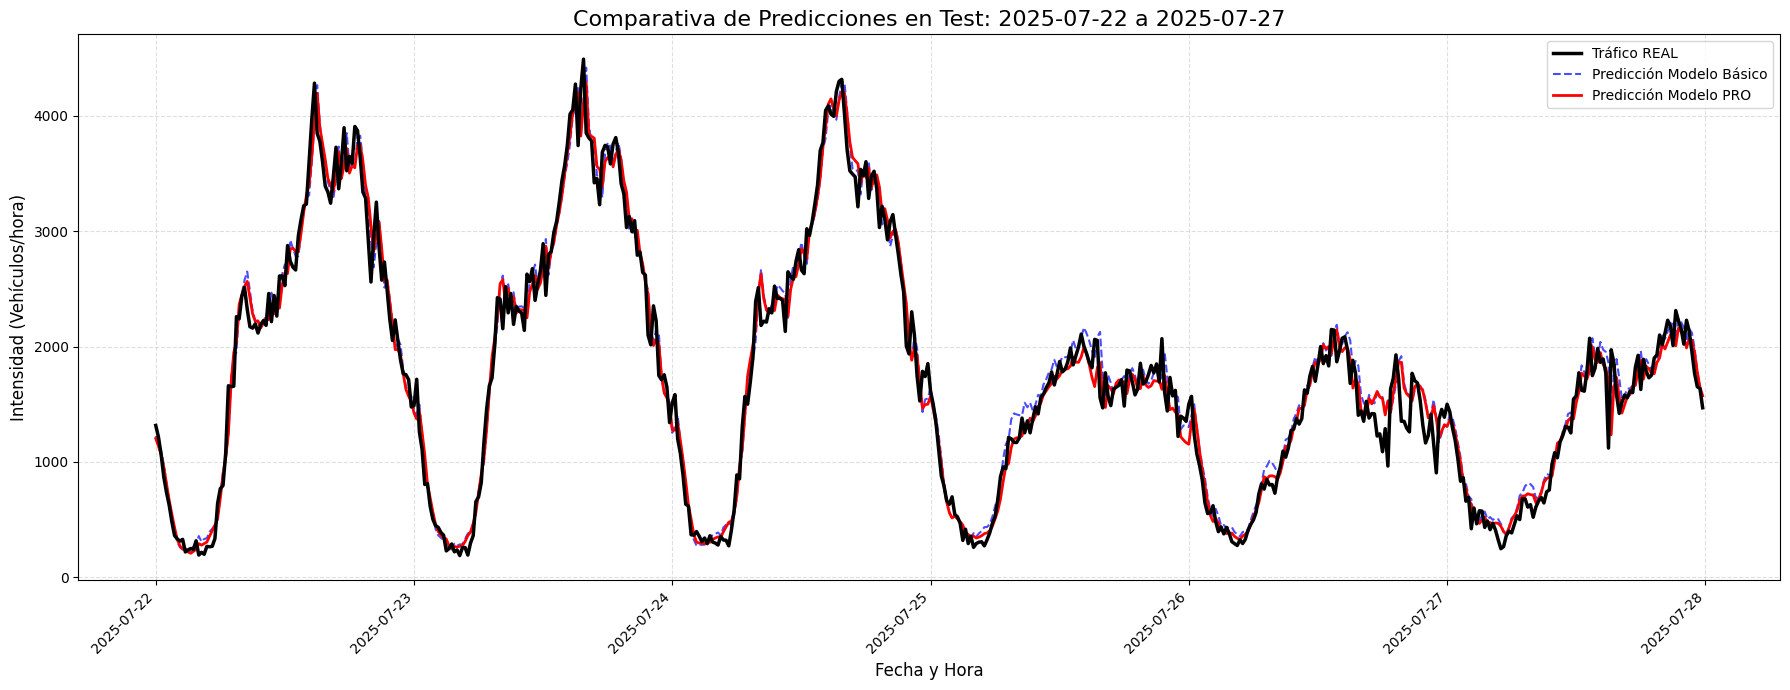

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Definimos los días específicos de Julio que queremos mostrar

# Para 3 días completos, necesitamos 3*96 = 288 puntos
start_date_plot = '2025-07-22 00:00:00' # Ejemplo: Lunes 22 de Julio
end_date_plot = '2025-07-27 23:45:00'   # Ejemplo: Miércoles 24 de Julio (justo antes del festivo)

# Filtramos df_resultados por el rango de fechas
subset_plot = df_resultados.loc[start_date_plot:end_date_plot]

if not subset_plot.empty:
    plt.figure(figsize=(18, 7))
    plt.plot(subset_plot.index, subset_plot['Realidad'], label='Tráfico REAL', color='black', linewidth=2.5, zorder=3)
    plt.plot(subset_plot.index, subset_plot['Basico'], label='Predicción Modelo Básico', color='blue', linestyle='--', alpha=0.7)
    plt.plot(subset_plot.index, subset_plot['PRO'], label='Predicción Modelo PRO', color='red', linewidth=2)

    plt.title(f'Comparativa de Predicciones en Test: {start_date_plot.split(" ")[0]} a {end_date_plot.split(" ")[0]}', fontsize=16)
    plt.xlabel('Fecha y Hora', fontsize=12)
    plt.ylabel('Intensidad (Vehículos/hora)', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print(f"[ERROR] No se encontraron datos para el rango de fechas especificado: {start_date_plot} a {end_date_plot}")

### **A: Escenario de Festivo:** *(Santiago Apóstol - 25 de Julio)*


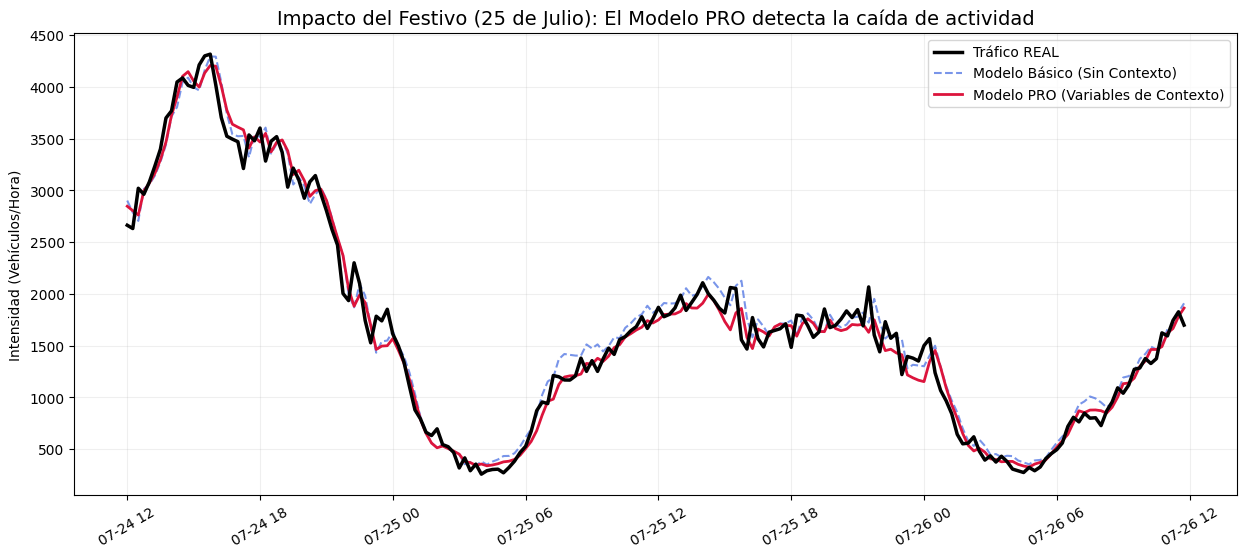

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuramos el desfase exacto
window_size = 672
first_ts = df_test.index[window_size]

# Rango del festivo
start, end = '2025-07-24 12:00:00', '2025-07-26 12:00:00'

# Cálculo de índices
s_idx = int((pd.to_datetime(start) - first_ts).total_seconds() // 900)
e_idx = int((pd.to_datetime(end) - first_ts).total_seconds() // 900)

plt.figure(figsize=(15, 6))
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], y_test_real[s_idx:e_idx],
         label='Tráfico REAL', color='black', lw=2.5, zorder=3)
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], pred_m1_real[s_idx:e_idx],
         label='Modelo Básico (Sin Contexto)', color='royalblue', ls='--', alpha=0.7)
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], pred_m2_real[s_idx:e_idx],
         label='Modelo PRO (Variables de Contexto)', color='crimson', lw=2)

plt.title('Impacto del Festivo (25 de Julio): El Modelo PRO detecta la caída de actividad', fontsize=14)
plt.ylabel('Intensidad (Vehículos/Hora)')
plt.grid(True, alpha=0.2)
plt.legend()
plt.xticks(rotation=30)
plt.show()

### **B: Escenario de Fin de Semana:** *(Sábado 12 y Domingo 13 de Julio)*


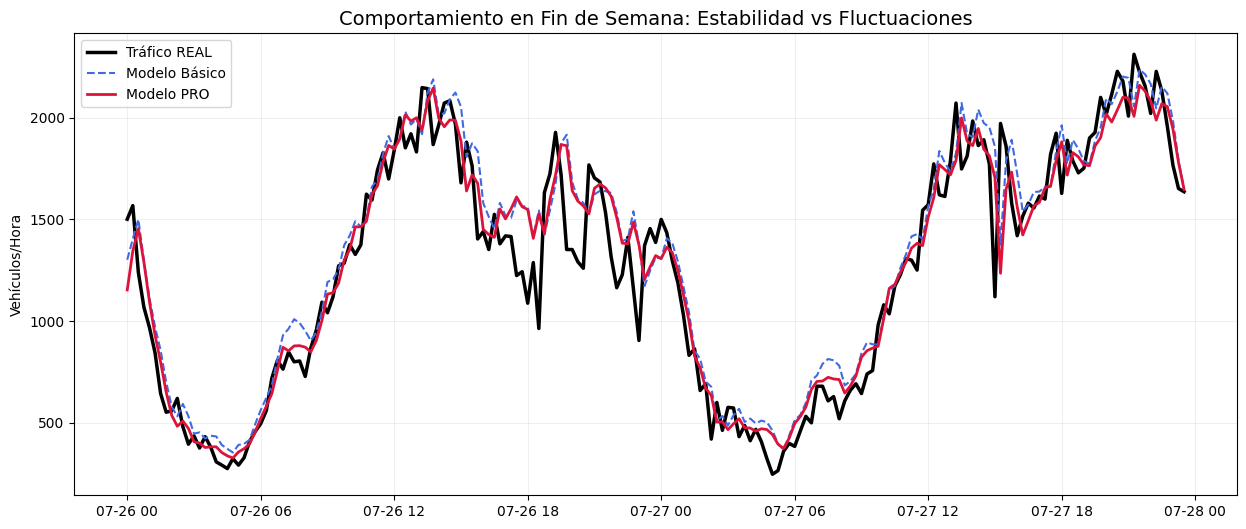

In [14]:
# Rango del fin de semana
start, end = '2025-07-26 00:00:00', '2025-07-27 23:45:00'

s_idx = int((pd.to_datetime(start) - first_ts).total_seconds() // 900)
e_idx = int((pd.to_datetime(end) - first_ts).total_seconds() // 900)

plt.figure(figsize=(15, 6))
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], y_test_real[s_idx:e_idx],
         label='Tráfico REAL', color='black', lw=2.5)
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], pred_m1_real[s_idx:e_idx],
         label='Modelo Básico', color='royalblue', ls='--')
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], pred_m2_real[s_idx:e_idx],
         label='Modelo PRO', color='crimson', lw=2)

plt.title('Comportamiento en Fin de Semana: Estabilidad vs Fluctuaciones', fontsize=14)
plt.ylabel('Vehículos/Hora')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

### **C: Zoom Hora Punta:** *(Lunes 21 de Julio por la mañana)*

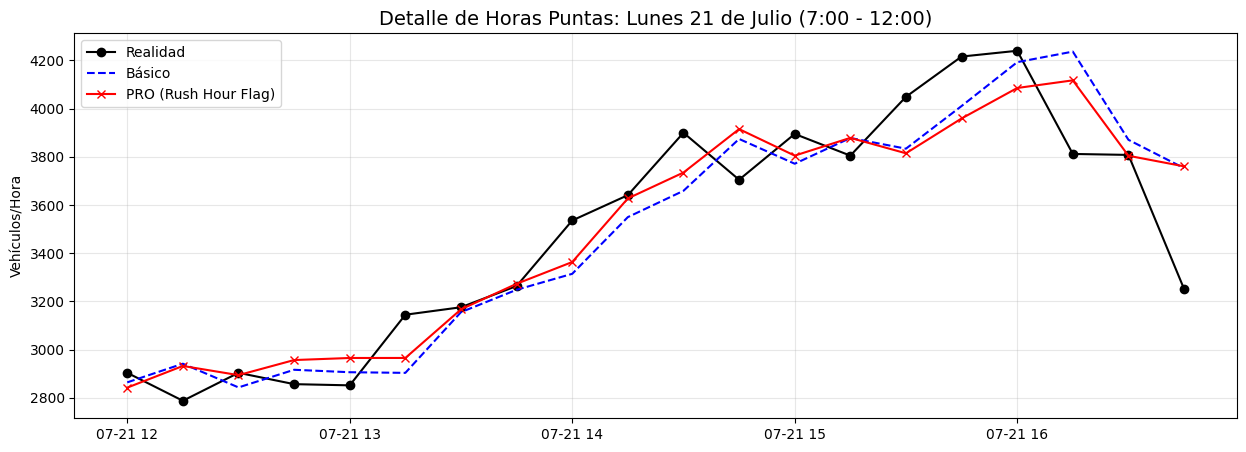

In [15]:
# 3. Definir rango: Mañana de un lunes (Horas Puntas)
start, end = '2025-07-21 12:00:00', '2025-07-21 17:00:00'

s_idx = int((pd.to_datetime(start) - first_ts).total_seconds() // 900)
e_idx = int((pd.to_datetime(end) - first_ts).total_seconds() // 900)

plt.figure(figsize=(15, 5))
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], y_test_real[s_idx:e_idx], label='Realidad', color='black', marker='o')
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], pred_m1_real[s_idx:e_idx], label='Básico', color='blue', ls='--')
plt.plot(df_test.index[window_size+s_idx : window_size+e_idx], pred_m2_real[s_idx:e_idx], label='PRO (Rush Hour Flag)', color='red', marker='x')

plt.title('Detalle de Horas Puntas: Lunes 21 de Julio (7:00 - 12:00)', fontsize=14)
plt.ylabel('Vehículos/Hora')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [20]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1. Aseguramos que el año sea el correcto (cámbialo si es necesario)
ANIO = "2025"

# 2. Definimos los escenarios que queremos comparar
escenarios = {
    "Global (Todo Julio)": (f"{ANIO}-07-13", f"{ANIO}-07-31"),
    "Día Festivo (Santiago)": (f"{ANIO}-07-25 00:00", f"{ANIO}-07-25 23:45"),
    "Fin de Semana": (f"{ANIO}-07-26 00:00", f"{ANIO}-07-27 23:45"),
    "Hora Punta (Lunes)": (f"{ANIO}-07-21 07:00", f"{ANIO}-07-21 12:00"),
    "Madrugada (Bajo tráfico)": (f"{ANIO}-07-22 01:00", f"{ANIO}-07-22 05:00")
}

# 3. Calculamos los datos
resultados_tabla = []

for nombre, (inicio, fin) in escenarios.items():
    subset = df_resultados.loc[inicio:fin]
    if not subset.empty:
        mae_1 = mean_absolute_error(subset['Realidad'], subset['Basico'])
        mae_2 = mean_absolute_error(subset['Realidad'], subset['PRO'])

        # Diferencia porcentual
        mejora = ((mae_1 - mae_2) / mae_1) * 100
        ganador = "Modelo PRO" if mae_2 < mae_1 else "Modelo Básico 📉"

        resultados_tabla.append({
            "Escenario": nombre,
            "MAE Básico (veh/h)": round(mae_1, 2),
            "MAE PRO (veh/h)": round(mae_2, 2),
            "Mejora (%)": f"{mejora:.2f}%",
            "Mejor Modelo": ganador
        })

# 4. Mostramos la tabla final
df_comparativo = pd.DataFrame(resultados_tabla)
print("TABLA COMPARATIVA DE PRECISIÓN")
display(df_comparativo)

TABLA COMPARATIVA DE PRECISIÓN


,Escenario,MAE Básico (veh/h),MAE PRO (veh/h),Mejora (%),Mejor Modelo
0,Global (Todo Julio),144.40,133.17,7.78%,Modelo PRO
1,Día Festivo (Santiago),113.92,96.58,15.21%,Modelo PRO
2,Fin de Semana,140.22,123.10,12.21%,Modelo PRO
3,Hora Punta (Lunes),121.68,104.86,13.83%,Modelo PRO
4,Madrugada (Bajo tráfico),66.11,55.39,16.21%,Modelo PRO


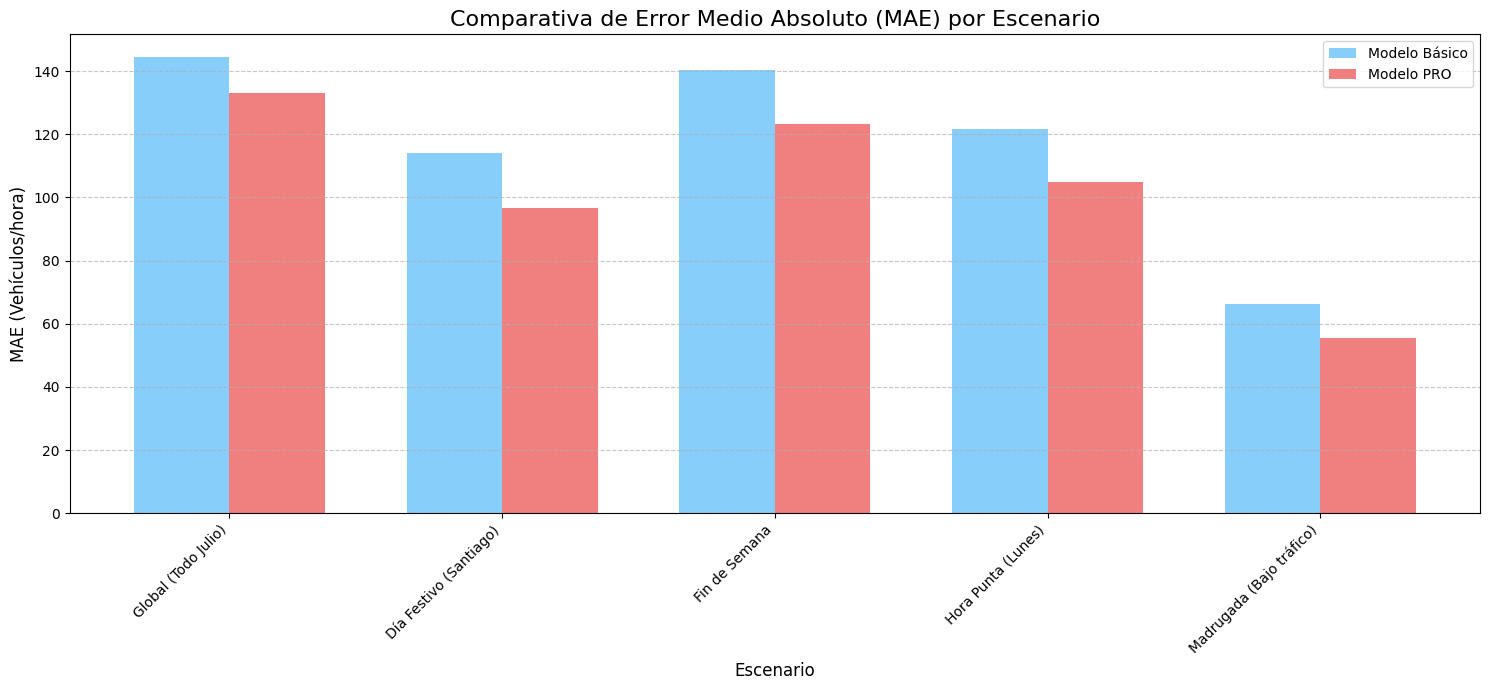

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

if 'df_comparativo' in locals():

    # Convertimos columnas MAE a numérico para poder graficar
    df_comparativo['MAE Básico (veh/h)_num'] = df_comparativo['MAE Básico (veh/h)']
    df_comparativo['MAE PRO (veh/h)_num'] = df_comparativo['MAE PRO (veh/h)']

    n_scenarios = len(df_comparativo)
    index = np.arange(n_scenarios)
    bar_width = 0.35

    plt.figure(figsize=(15, 7))

    plt.bar(index, df_comparativo['MAE Básico (veh/h)_num'], bar_width, label='Modelo Básico', color='lightskyblue')
    plt.bar(index + bar_width, df_comparativo['MAE PRO (veh/h)_num'], bar_width, label='Modelo PRO', color='lightcoral')

    plt.xlabel('Escenario', fontsize=12)
    plt.ylabel('MAE (Vehículos/hora)', fontsize=12)
    plt.title('Comparativa de Error Medio Absoluto (MAE) por Escenario', fontsize=16)
    plt.xticks(index + bar_width / 2, df_comparativo['Escenario'], rotation=45, ha='right', fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("[ERROR] df_comparativo no encontrado. Asegúrate de ejecutar la celda de 'Análisis por Escenarios' primero.")

In [18]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Calculamos el error real en vehículos/hora
mae_basico = mean_absolute_error(df_resultados['Realidad'], df_resultados['Basico'])
mae_pro = mean_absolute_error(df_resultados['Realidad'], df_resultados['PRO'])

# 2. Calculamos el R2 (Este es el que le gusta a los profesores)
r2_basico = r2_score(df_resultados['Realidad'], df_resultados['Basico'])
r2_pro = r2_score(df_resultados['Realidad'], df_resultados['PRO'])

print(f"RESULTADOS FINALES REALES")
print("-" * 30)
print(f"Modelo Básico:")
print(f"  - Error Medio (MAE): {mae_basico:.2f} veh/h")
print(f"  - Precisión (R2): {r2_basico:.4f}")
print("-" * 30)
print(f"Modelo PRO:")
print(f"  - Error Medio (MAE): {mae_pro:.2f} veh/h")
print(f"  - Precisión (R2): {r2_pro:.4f}")

# 3. Porcentaje de mejora real
mejora = ((mae_basico - mae_pro) / mae_basico) * 100
print(f"\nCONCLUSIÓN: El Modelo PRO es un {mejora:.2f}% más preciso que el básico.")

RESULTADOS FINALES REALES
------------------------------
Modelo Básico:
  - Error Medio (MAE): 144.10 veh/h
  - Precisión (R2): 0.9701
------------------------------
Modelo PRO:
  - Error Medio (MAE): 133.29 veh/h
  - Precisión (R2): 0.9733

CONCLUSIÓN: El Modelo PRO es un 7.50% más preciso que el básico.


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# Filtrar valores bajos para MAPE

mask = y_test_real > 50  # ajusta este umbral si quieres

y_test_eval = y_test_real[mask]
pred_m1_eval = pred_m1_real[mask]
pred_m2_eval = pred_m2_real[mask]


# Métricas MODELO BÁSICO
mae_m1 = mean_absolute_error(y_test_eval, pred_m1_eval)
rmse_m1 = np.sqrt(mean_squared_error(y_test_eval, pred_m1_eval))
r2_m1 = r2_score(y_test_eval, pred_m1_eval)
mape_m1 = mean_absolute_percentage_error(y_test_eval, pred_m1_eval)

# Métricas MODELO PRO
mae_m2 = mean_absolute_error(y_test_eval, pred_m2_eval)
rmse_m2 = np.sqrt(mean_squared_error(y_test_eval, pred_m2_eval))
r2_m2 = r2_score(y_test_eval, pred_m2_eval)
mape_m2 = mean_absolute_percentage_error(y_test_eval, pred_m2_eval)

# Precisión (%)
precision_m1 = (1 - mape_m1) * 100
precision_m2 = (1 - mape_m2) * 100

# Margen de mejora entre modelos
improvement_mae = ((mae_m1 - mae_m2) / mae_m1) * 100
improvement_mape = ((mape_m1 - mape_m2) / mape_m1) * 100

# Tabla Comparativa
metrics_data = {
    'Métrica': [
        'MAE (veh/h)',
        'RMSE (veh/h)',
        'R²',
        'MAPE (%)',
        'Precisión (%)'
    ],
    'Modelo 1 (Básico)': [
        f"{mae_m1:.2f}",
        f"{rmse_m1:.2f}",
        f"{r2_m1:.4f}",
        f"{mape_m1*100:.2f}%",
        f"{precision_m1:.2f}%"
    ],
    'Modelo 2 (PRO)': [
        f"{mae_m2:.2f}",
        f"{rmse_m2:.2f}",
        f"{r2_m2:.4f}",
        f"{mape_m2*100:.2f}%",
        f"{precision_m2:.2f}%"
    ]
}

df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)


print(f"Modelo 1 --> Error medio: {mape_m1*100:.2f}% | Precisión: {precision_m1:.2f}%")
print(f"Modelo 2 --> Error medio: {mape_m2*100:.2f}% | Precisión: {precision_m2:.2f}%")

print(f"\nEl Modelo PRO reduce el MAE en un {improvement_mae:.2f}% respecto al modelo básico.")
print(f"Además, reduce el error porcentual (MAPE) en un {improvement_mape:.2f}%.")

print("\nConclusión:\nEl modelo PRO presenta una mejora consistente, aunque moderada, sobre el modelo básico,\nmanteniendo un alto nivel de precisión en la predicción del tráfico.")

,Métrica,Modelo 1 (Básico),Modelo 2 (PRO)
0,MAE (veh/h),143.80,132.51
1,RMSE (veh/h),200.88,188.24
2,R²,0.9702,0.9738
3,MAPE (%),10.77%,9.62%
4,Precisión (%),89.23%,90.38%


Modelo 1 --> Error medio: 10.77% | Precisión: 89.23%
Modelo 2 --> Error medio: 9.62% | Precisión: 90.38%

El Modelo PRO reduce el MAE en un 7.85% respecto al modelo básico.
Además, reduce el error porcentual (MAPE) en un 10.68%.

Conclusión:
El modelo PRO presenta una mejora consistente, aunque moderada, sobre el modelo básico,
manteniendo un alto nivel de precisión en la predicción del tráfico.
